# 1. Project Introduction

## IMDB Movies Dataset Analysis: What Makes a Movie Successful?

This notebook is Step 1 of the project. It focuses only on data exploration, data cleaning, exploratory data analysis, and visualization. The analysis uses `movies_metadata.csv` as the main dataset and does not implement machine learning, a recommendation system, or LLM-related features.

Movie success is defined from four perspectives:

- **Commercial performance:** revenue and profit
- **Investment efficiency:** ROI, calculated as profit divided by budget
- **Audience response:** vote average, vote count, and popularity
- **Industry trend:** changes in movie production volume, budget, revenue, and rating over time

The main research question is: **What factors are associated with movie success?**

# 2. Dataset Overview

**Research question:** What data files are available, and what is the quality of the main movie metadata table?

This section inventories the dataset package before analysis. Other CSV files are listed only for overview; Step 1 does not merge them with `movies_metadata.csv`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_cleaning import build_dataset_inventory, clean_movies_metadata, format_inventory_markdown
from src.visualization import create_all_figures, genre_metric_table, yearly_count_table, yearly_mean_table

DATA_DIR = PROJECT_ROOT / "data"
METADATA_PATH = DATA_DIR / "movies_metadata.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
CLEANED_PATH = OUTPUT_DIR / "cleaned_movies.csv"
FINANCIAL_PATH = OUTPUT_DIR / "financial_movies.csv"
SUMMARY_PATH = OUTPUT_DIR / "data_analysis_summary.md"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

inventory = build_dataset_inventory(DATA_DIR)
display(Markdown(format_inventory_markdown(inventory)))

## Dataset Overview

- Detected CSV files: credits.csv, keywords.csv, links.csv, links_small.csv, movies_metadata.csv, ratings.csv, ratings_small.csv
- `movies_metadata.csv` shape: 45,466 rows x 24 columns
- Duplicate movie count based on numeric id: 62
- Invalid budget rows for financial analysis: 36,576
- Invalid revenue rows for financial analysis: 38,058
- Rows usable for financial analysis: 5,381
- Malformed/non-numeric movie id rows: 3

### Columns

`adult`, `belongs_to_collection`, `budget`, `genres`, `homepage`, `id`, `imdb_id`, `original_language`, `original_title`, `overview`, `popularity`, `poster_path`, `production_companies`, `production_countries`, `release_date`, `revenue`, `runtime`, `spoken_languages`, `status`, `tagline`, `title`, `video`, `vote_average`, `vote_count`

### Key Column Data Types

- `id`: str
- `title`: str
- `budget`: str
- `revenue`: float64
- `genres`: str
- `release_date`: str
- `original_language`: str
- `runtime`: float64
- `popularity`: str
- `vote_average`: float64
- `vote_count`: float64

### Missing Values in Key Columns

- `id`: 0
- `title`: 6
- `budget`: 0
- `revenue`: 6
- `genres`: 0
- `release_date`: 87
- `original_language`: 11
- `runtime`: 263
- `popularity`: 5
- `vote_average`: 6
- `vote_count`: 6

In [2]:
inventory_table = pd.DataFrame({
    "Item": [
        "Detected CSV files",
        "movies_metadata.csv shape",
        "Duplicate movie count",
        "Invalid budget rows",
        "Invalid revenue rows",
        "Rows usable for financial analysis",
        "Malformed/non-numeric movie id rows",
    ],
    "Value": [
        ", ".join(inventory["csv_files"]),
        f"{inventory['movies_shape'][0]:,} rows x {inventory['movies_shape'][1]:,} columns",
        f"{inventory['duplicate_movie_count']:,}",
        f"{inventory['invalid_budget_rows']:,}",
        f"{inventory['invalid_revenue_rows']:,}",
        f"{inventory['financial_analysis_rows']:,}",
        f"{inventory['malformed_id_rows']:,}",
    ],
})
inventory_table

,Item,Value
0,Detected CSV files,"credits.csv, keywords.csv, links.csv, links_sm..."
1,movies_metadata.csv shape,"45,466 rows x 24 columns"
2,Duplicate movie count,62
3,Invalid budget rows,"36,576"
4,Invalid revenue rows,"38,058"
5,Rows usable for financial analysis,"5,381"
6,Malformed/non-numeric movie id rows,3


**Short interpretation:** The dataset contains a broad movie metadata table, but financial fields have many invalid zero or missing values. Because zero budget and zero revenue are not reliable true values, financial analysis must use a separate valid financial subset rather than deleting those rows from the main dataset.

# 3. Data Cleaning

**Research question:** How can the metadata be cleaned without losing useful non-financial movie records?

The cleaning pipeline converts important fields to safe numeric or datetime types, removes malformed and duplicate movie records, parses genres, and preserves the main dataset for non-financial analysis. Positive budget and revenue are required only for the separate financial-analysis dataset.

In [3]:
cleaned_movies, financial_movies, cleaning_summary = clean_movies_metadata(
    METADATA_PATH,
    output_path=CLEANED_PATH,
    financial_output_path=FINANCIAL_PATH,
)

pd.DataFrame([
    ("Raw rows", f"{cleaning_summary['raw_rows']:,}"),
    ("Cleaned rows", f"{cleaning_summary['cleaned_rows']:,}"),
    ("Malformed rows removed", f"{cleaning_summary['malformed_rows_removed']:,}"),
    ("Duplicate rows removed", f"{cleaning_summary['duplicate_rows_removed']:,}"),
    ("Invalid budget rows", f"{cleaning_summary['invalid_budget_rows']:,}"),
    ("Invalid revenue rows", f"{cleaning_summary['invalid_revenue_rows']:,}"),
    ("Rows in financial dataset", f"{cleaning_summary['financial_rows']:,}"),
    ("Financial dataset file", str(FINANCIAL_PATH.relative_to(PROJECT_ROOT))),
], columns=["Cleaning item", "Value"])

,Cleaning item,Value
0,Raw rows,"45,466"
1,Cleaned rows,"45,433"
2,Malformed rows removed,3
3,Duplicate rows removed,30
4,Invalid budget rows,"36,573"
5,Invalid revenue rows,"38,055"
6,Rows in financial dataset,"5,375"
7,Financial dataset file,outputs\financial_movies.csv


In [4]:
cleaned_movies[[
    "movie_id", "title", "budget", "revenue", "profit", "roi",
    "main_genre", "release_year", "popularity", "vote_average", "vote_count"
]].head()

,movie_id,title,budget,revenue,profit,roi,main_genre,release_year,popularity,vote_average,vote_count
0,862.0,Toy Story,30000000,373554033.0,343554033.0,11.451801,Animation,1995.0,21.946943,7.7,5415.0
1,8844.0,Jumanji,65000000,262797249.0,197797249.0,3.043035,Adventure,1995.0,17.015539,6.9,2413.0
2,15602.0,Grumpier Old Men,0,0.0,<NA>,<NA>,Romance,1995.0,11.712900,6.5,92.0
3,31357.0,Waiting to Exhale,16000000,81452156.0,65452156.0,4.09076,Comedy,1995.0,3.859495,6.1,34.0
4,11862.0,Father of the Bride Part II,0,76578911.0,<NA>,<NA>,Comedy,1995.0,8.387519,5.7,173.0


**Short interpretation:** The cleaning stage removes only clearly problematic duplicate or malformed movie records. Rows with zero or missing budget/revenue remain in the cleaned main dataset, while the valid financial subset is reserved for budget, revenue, profit, and ROI analysis.

# 4. Feature Engineering

**Research question:** Which additional variables help connect movie metadata to different definitions of success?

The analysis adds `release_year`, `genre_list`, `main_genre`, `profit`, `roi`, `budget_group`, and `rating_group` where the required source columns are available. These features make it possible to compare commercial performance, investment efficiency, audience response, and trends over time.

In [5]:
feature_summary = pd.DataFrame([
    ("release_year", "Extracted from release_date for time trend analysis"),
    ("genre_list", "Parsed from the genres text field"),
    ("main_genre", "First listed genre, used as the primary genre label"),
    ("profit", "revenue - budget, calculated only when budget and revenue are positive"),
    ("roi", "profit / budget, calculated only for valid financial rows"),
    ("budget_group", "Low / Medium / High quantile groups based on positive budget"),
    ("rating_group", "Low / Medium / High quantile groups based on vote_average"),
], columns=["Feature", "Purpose"])
feature_summary

,Feature,Purpose
0,release_year,Extracted from release_date for time trend ana...
1,genre_list,Parsed from the genres text field
2,main_genre,"First listed genre, used as the primary genre ..."
3,profit,"revenue - budget, calculated only when budget ..."
4,roi,"profit / budget, calculated only for valid fin..."
5,budget_group,Low / Medium / High quantile groups based on p...
6,rating_group,Low / Medium / High quantile groups based on v...


In [6]:
created_features = ["release_year", "genre_list", "main_genre", "profit", "roi", "budget_group", "rating_group"]
feature_missing = cleaned_movies[created_features].isna().sum().reset_index()
feature_missing.columns = ["Feature", "Missing rows"]
feature_missing

,Feature,Missing rows
0,release_year,87
1,genre_list,0
2,main_genre,2442
3,profit,40058
4,roi,40058
5,budget_group,36553
6,rating_group,3


**Short interpretation:** The engineered features separate financial validity from general movie metadata. This allows the notebook to answer financial questions with stricter data while still using broader metadata for genre, rating, and release-year questions.

# 5. Commercial Success Analysis

**Research question:** Does higher investment lead to stronger commercial success?

This section uses only movies where both budget and revenue are positive. The charts examine whether budget is associated with revenue, profit, and ROI. Log scale is used for budget and revenue where appropriate because movie financial data is highly skewed.

In [7]:
figure_paths = create_all_figures(cleaned_movies, financial_movies, FIGURES_DIR)
skipped_figures = {
    name: "Required columns were unavailable or the filtered dataset was empty."
    for name, path in figure_paths.items()
    if path is None
}

commercial_stats = {
    "budget_revenue_corr": financial_movies[["budget", "revenue"]].corr().iloc[0, 1],
    "budget_profit_corr": financial_movies[["budget", "profit"]].corr().iloc[0, 1],
}
roi_by_budget = financial_movies.groupby("budget_group")["roi"].median().reindex(["Low", "Medium", "High"])

pd.DataFrame({
    "Metric": ["Budget vs revenue correlation", "Budget vs profit correlation"],
    "Value": [commercial_stats["budget_revenue_corr"], commercial_stats["budget_profit_corr"]],
})

,Metric,Value
0,Budget vs revenue correlation,0.730286
1,Budget vs profit correlation,0.581708


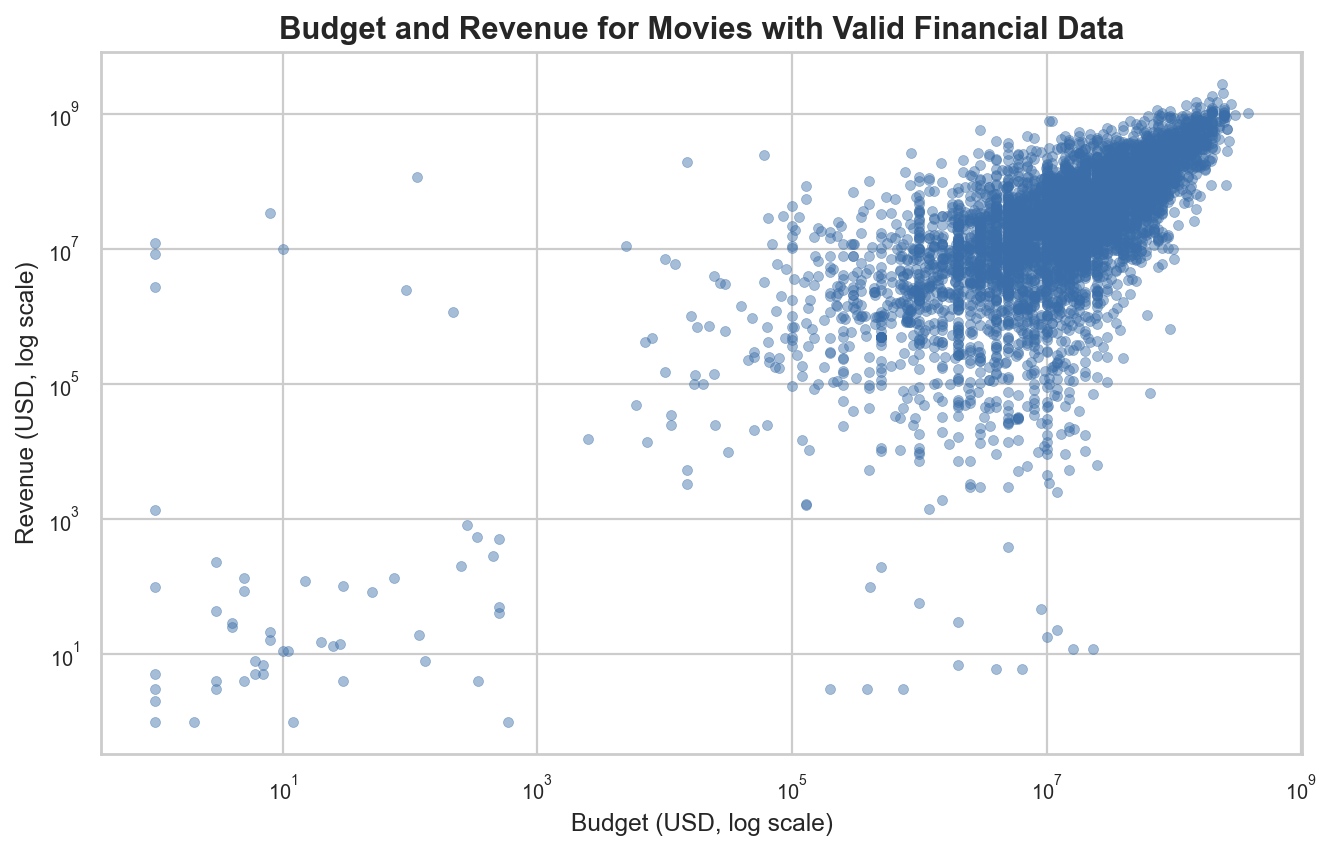

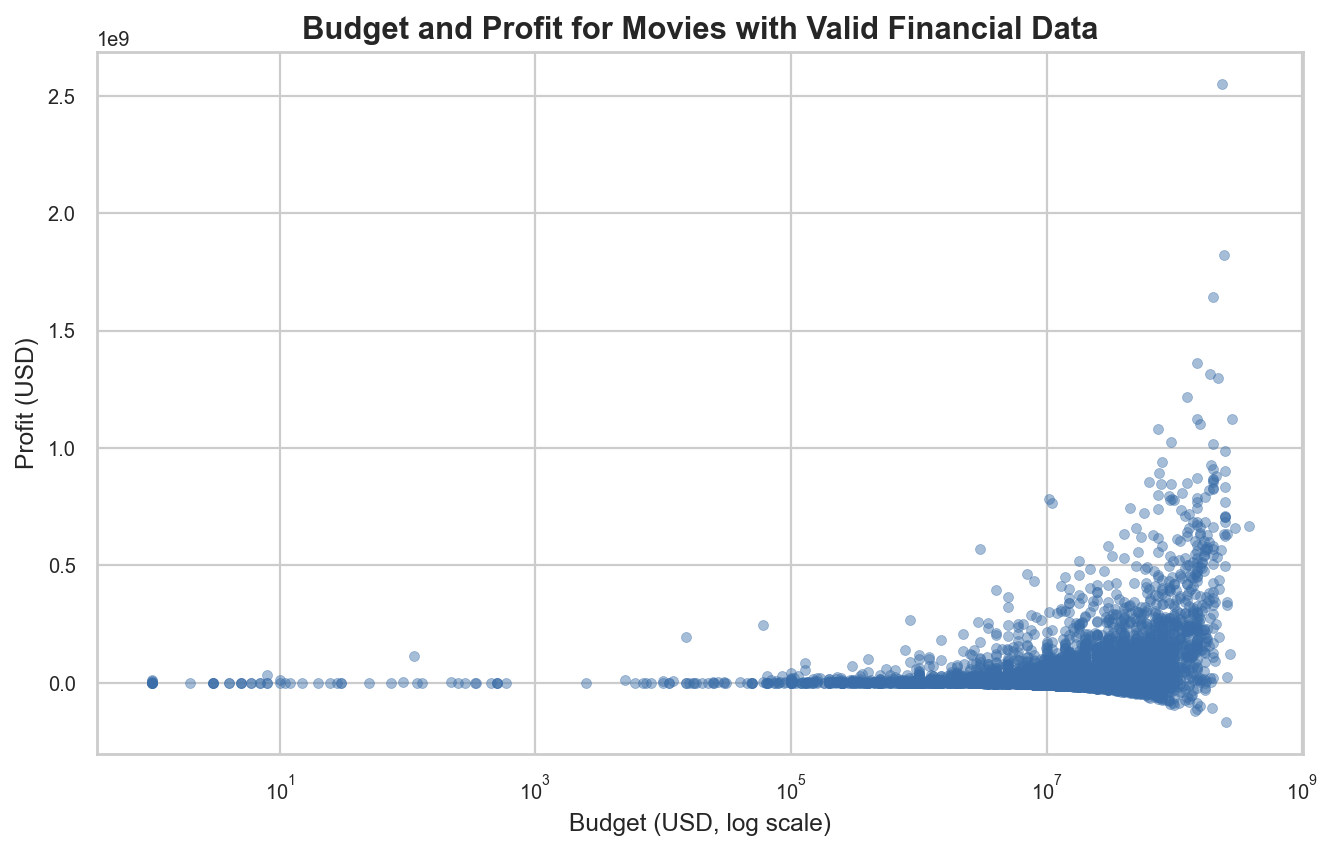

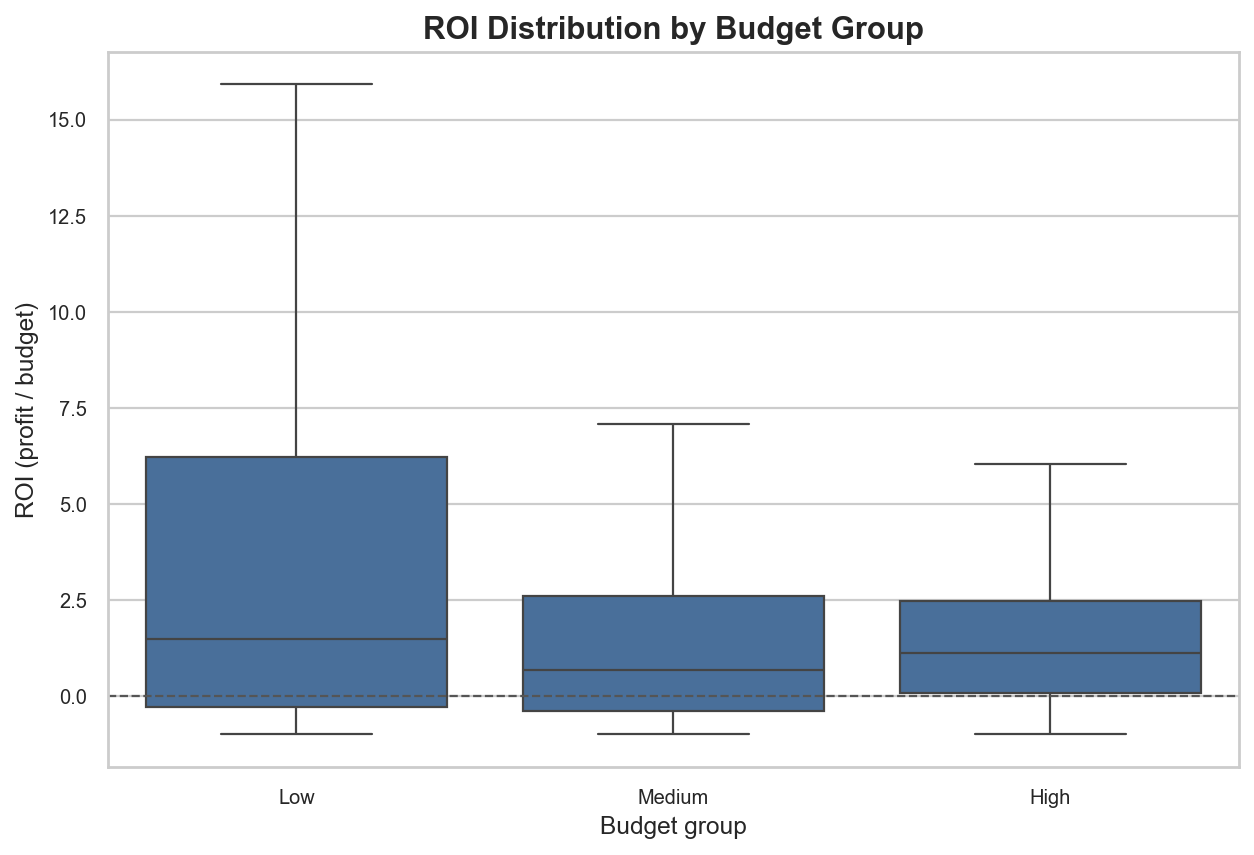

In [8]:
for figure_name in ["budget_vs_revenue.png", "budget_vs_profit.png", "roi_by_budget_group.png"]:
    path = figure_paths.get(figure_name)
    if path:
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**Skipped `{figure_name}`:** {skipped_figures.get(figure_name)}"))

In [9]:
roi_by_budget.reset_index().rename(columns={"budget_group": "Budget group", "roi": "Median ROI"})

,Budget group,Median ROI
0,Low,1.484567
1,Medium,0.676342
2,High,1.127484


**Short interpretation:** Higher budget is clearly associated with higher revenue potential, and the budget-profit relationship is also positive. However, the ROI chart shows that higher-budget movies do not automatically produce better investment efficiency. Commercial scale and investment efficiency are related but not identical definitions of success.

# 6. Genre Performance Analysis

**Research question:** Do different movie genres perform differently?

This section uses `main_genre`, extracted from the first listed genre in the metadata. To avoid conclusions dominated by very rare genres, revenue and ROI comparisons use genres with at least 30 valid financial records, while rating comparisons use genres with at least 100 rating records.

In [10]:
genre_revenue = genre_metric_table(financial_movies, "revenue", min_count=30, top_n=10)
genre_rating = genre_metric_table(cleaned_movies, "vote_average", min_count=100, top_n=10)
genre_roi = genre_metric_table(financial_movies, "roi", min_count=30, top_n=10)

display(Markdown("### Average Revenue by Genre"))
display(genre_revenue)
display(Markdown("### Average Rating by Genre"))
display(genre_rating)
display(Markdown("### Average ROI by Genre"))
display(genre_roi)

### Average Revenue by Genre

,main_genre,movie_count,revenue
2,Animation,146,2.408561e+08
7,Family,55,2.406010e+08
1,Adventure,413,1.999191e+08
15,Science Fiction,104,1.665982e+08
8,Fantasy,140,1.327448e+08
0,Action,961,1.230885e+08
17,Thriller,199,7.473545e+07
14,Romance,121,7.012801e+07
3,Comedy,1066,6.407535e+07
13,Mystery,67,5.609235e+07


### Average Rating by Genre

,main_genre,movie_count,vote_average
2,Animation,1123,6.305877
18,War,379,5.928760
6,Drama,11953,5.881544
4,Crime,1684,5.863717
12,Music,487,5.828337
5,Documentary,3413,5.805303
10,History,279,5.787814
9,Foreign,118,5.781356
1,Adventure,1509,5.745924
3,Comedy,8816,5.685878


### Average ROI by Genre

,main_genre,movie_count,roi
18,War,38,110460.991827
6,Drama,1314,15907.262719
11,Horror,325,3141.980137
3,Comedy,1066,2615.405740
1,Adventure,413,2470.294573
5,Documentary,48,127.086525
13,Mystery,67,6.529467
2,Animation,146,6.233525
19,Western,31,5.922252
7,Family,55,5.283752


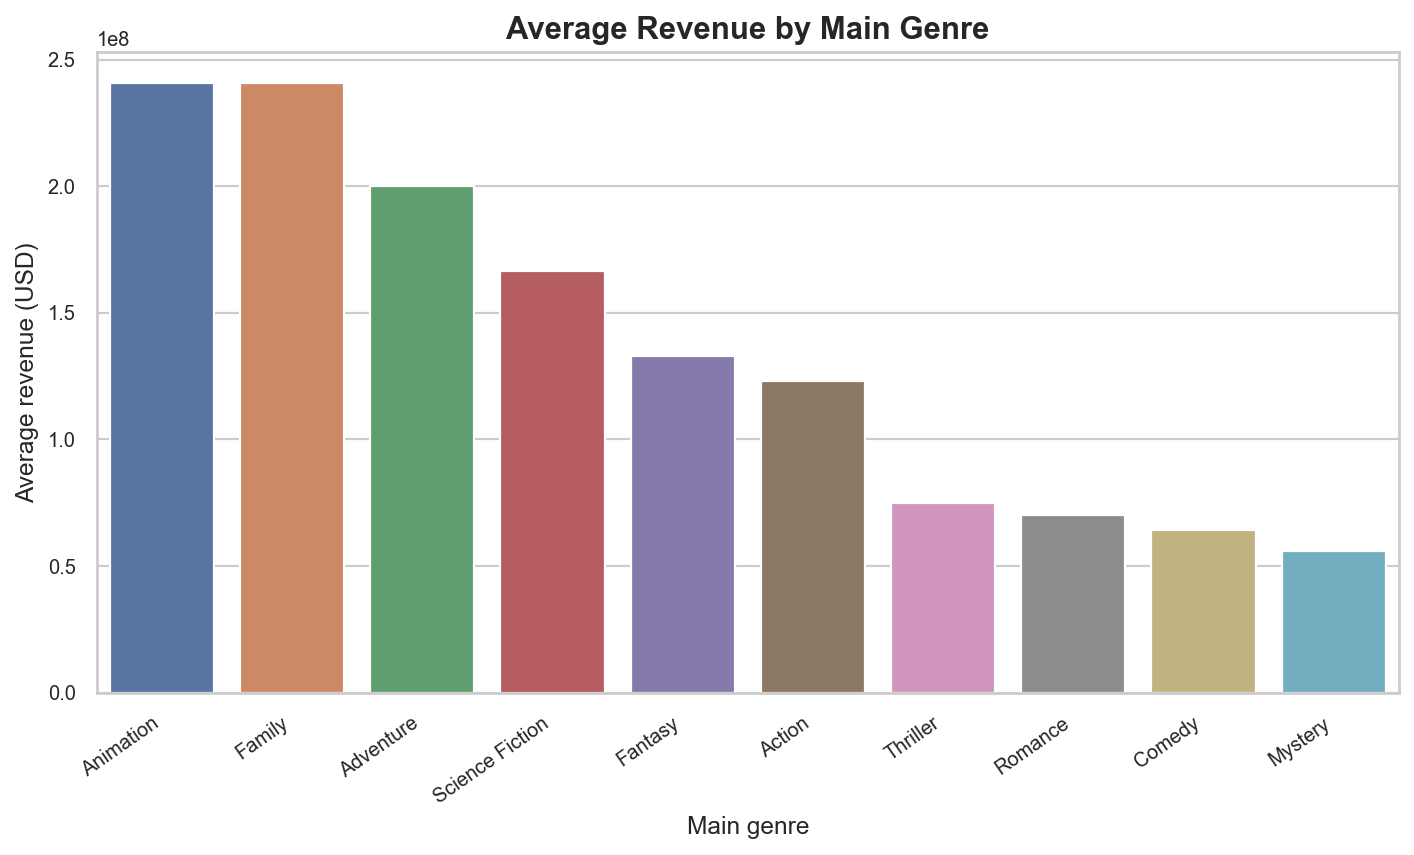

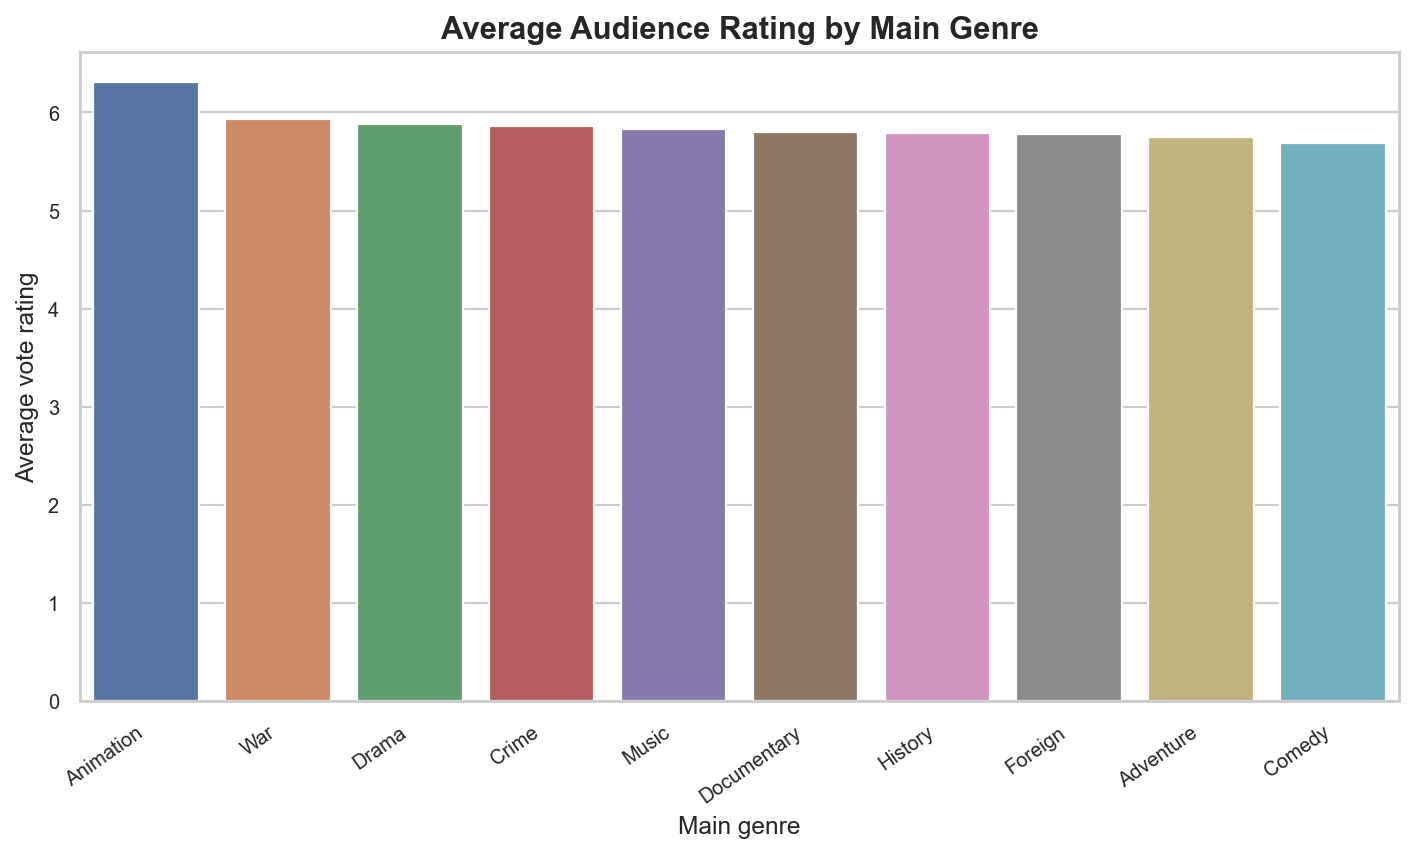

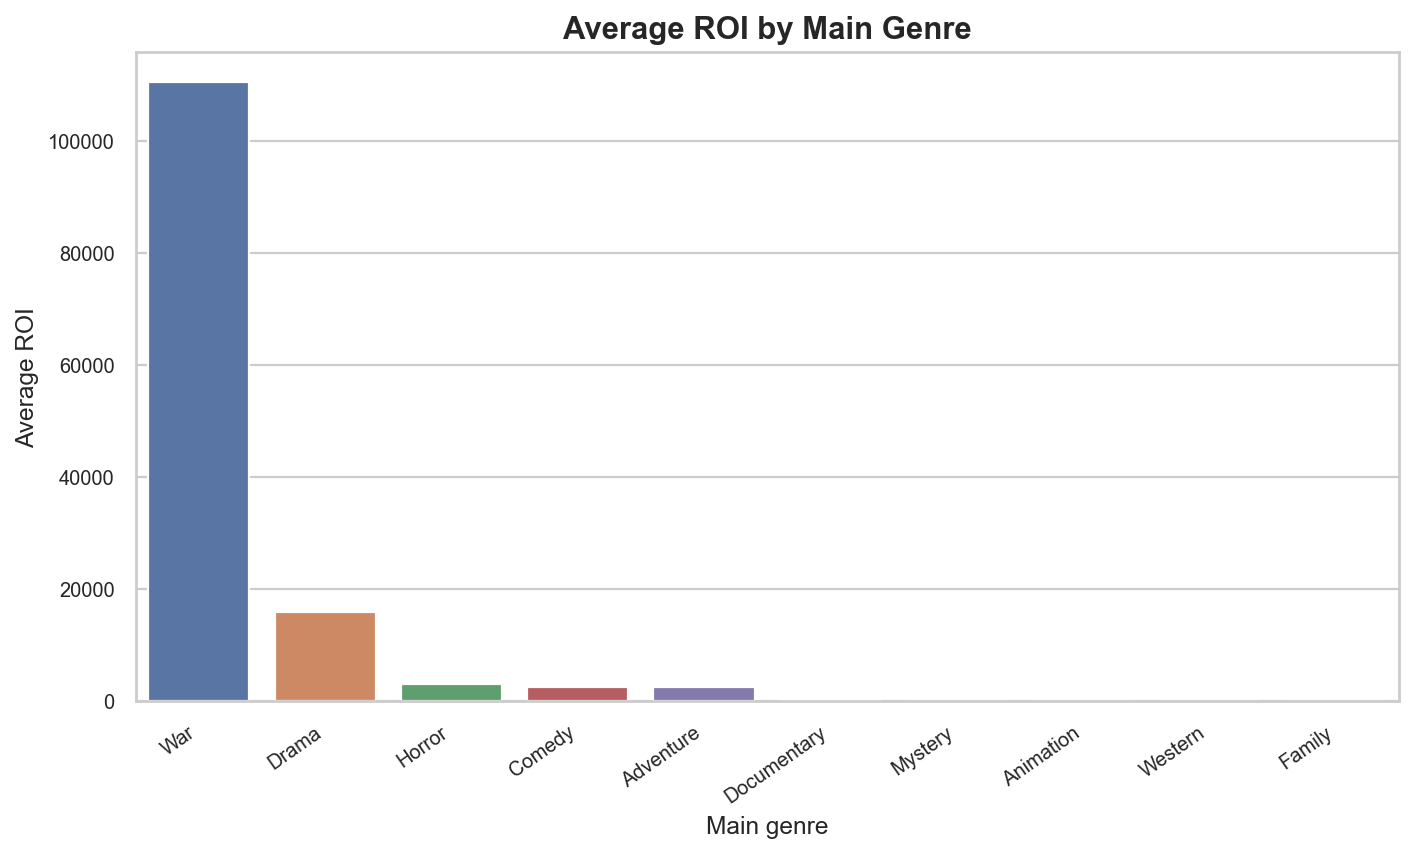

In [11]:
for figure_name in ["revenue_by_genre.png", "rating_by_genre.png", "roi_by_genre.png"]:
    path = figure_paths.get(figure_name)
    if path:
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**Skipped `{figure_name}`:** {skipped_figures.get(figure_name)}"))

**Short interpretation:** Genre affects different success perspectives in different ways. Some genres lead in average revenue, while a different set of genres may rank higher by audience rating or ROI. This supports the idea that commercial success and audience evaluation should be discussed separately.

# 7. Audience Response Analysis

**Research question:** Is audience rating or audience attention more related to commercial success?

This section compares revenue with vote average, vote count, and popularity. Vote average measures evaluation, while vote count and popularity are closer to audience attention or visibility.

In [12]:
audience_columns = [col for col in ["revenue", "vote_average", "vote_count", "popularity"] if col in financial_movies.columns]
audience_corr = financial_movies[audience_columns].corr(numeric_only=True)["revenue"].sort_values(ascending=False)
audience_corr.reset_index().rename(columns={"index": "Variable", "revenue": "Correlation with revenue"})

,Variable,Correlation with revenue
0,revenue,1.000000
1,vote_count,0.770559
2,popularity,0.440506
3,vote_average,0.167775


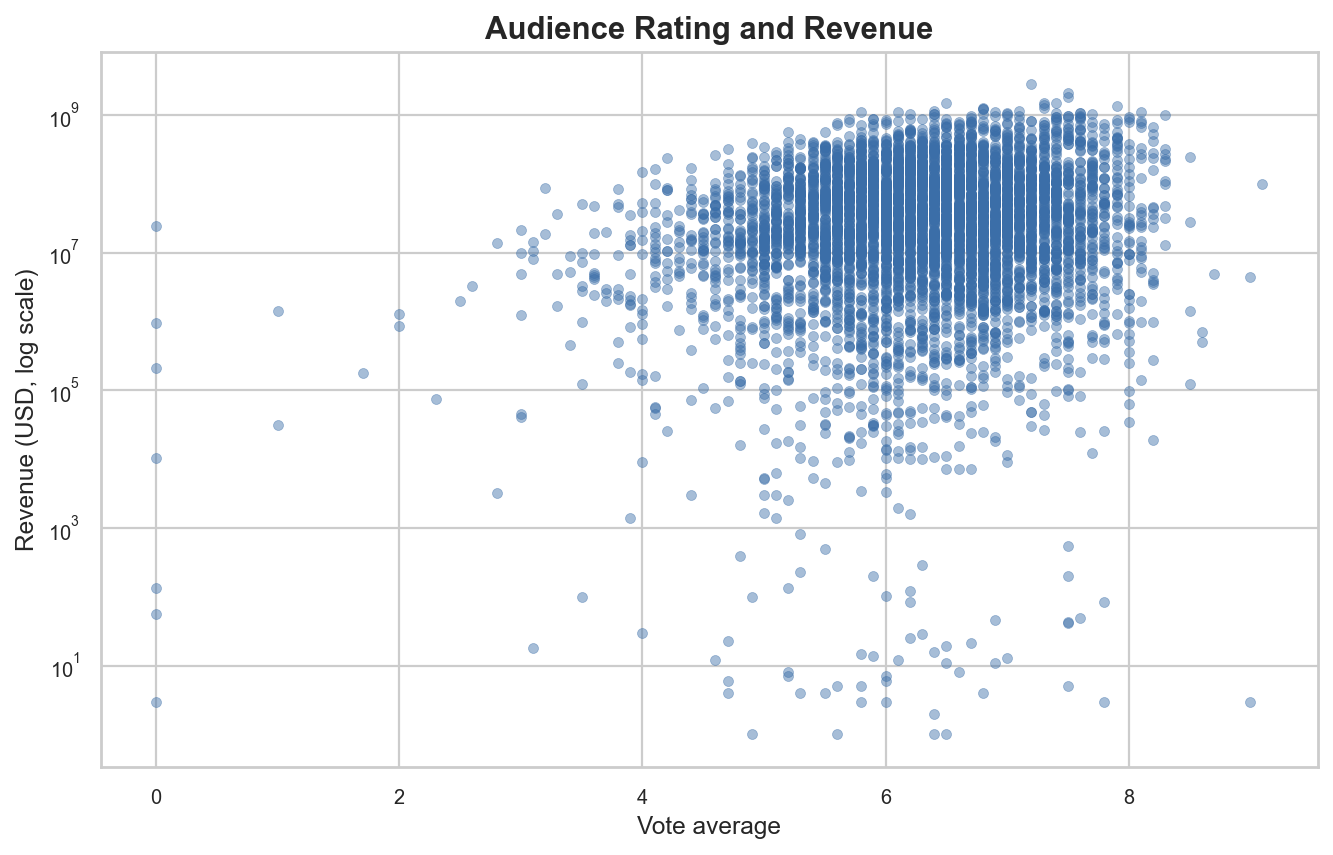

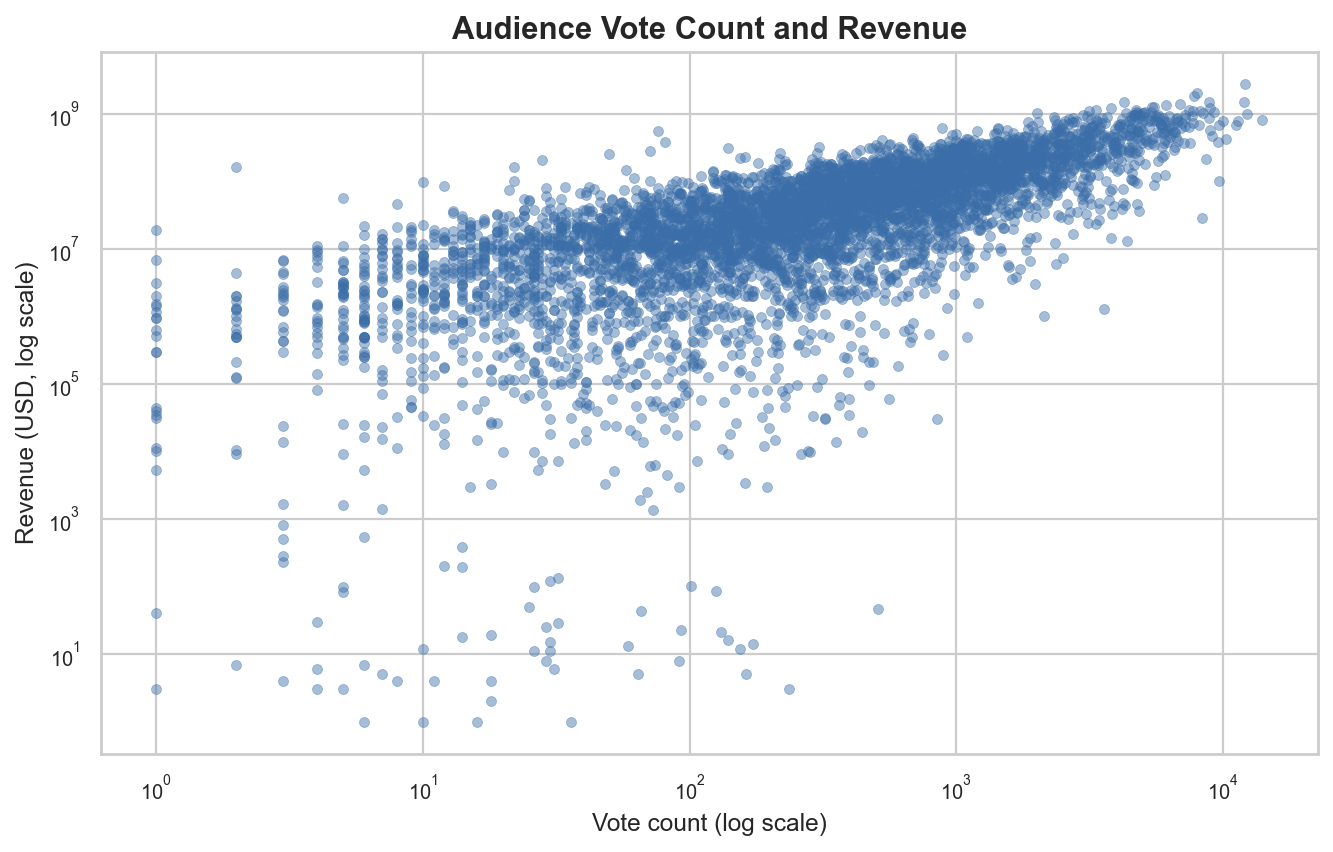

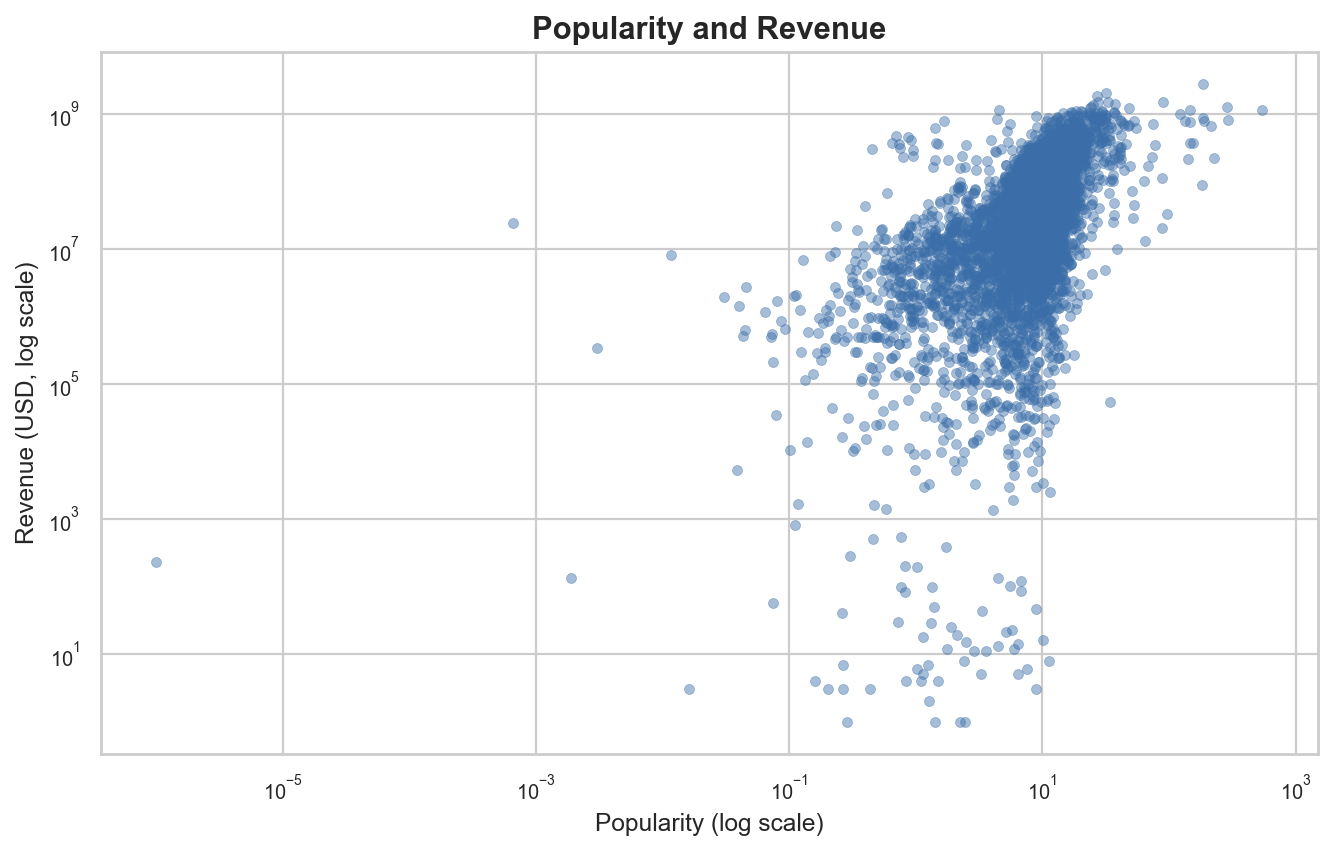

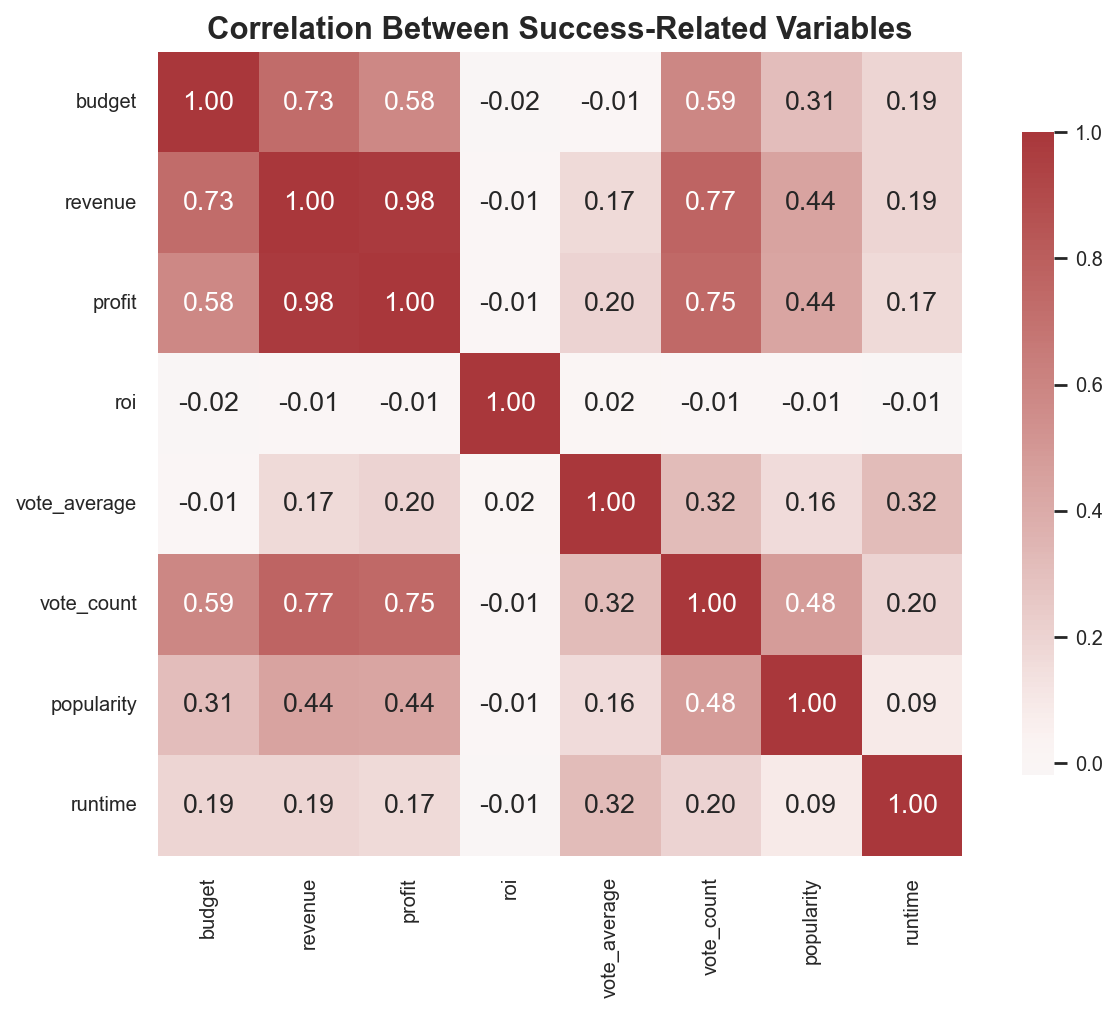

In [13]:
for figure_name in ["rating_vs_revenue.png", "vote_count_vs_revenue.png", "popularity_vs_revenue.png", "correlation_heatmap.png"]:
    path = figure_paths.get(figure_name)
    if path:
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**Skipped `{figure_name}`:** {skipped_figures.get(figure_name)}"))

**Short interpretation:** Audience rating and revenue are not the same concept. In this dataset, vote count and popularity are more closely connected to revenue than vote average alone, suggesting that audience attention is often more commercially relevant than rating score by itself.

# 8. Time Trend Analysis

**Research question:** How has the movie industry changed over time?

This section filters release years to a reasonable range and avoids over-interpreting years with very few records. Movie count and rating trends use the cleaned main dataset. Budget and revenue trends use only the valid financial dataset.

In [14]:
movies_by_year = yearly_count_table(cleaned_movies, min_count=5)
revenue_by_year = yearly_mean_table(financial_movies, "revenue", min_count=5)
budget_by_year = yearly_mean_table(financial_movies, "budget", min_count=5)
rating_by_year = yearly_mean_table(cleaned_movies, "vote_average", min_count=5)

time_summary = pd.DataFrame([
    ("Peak release-count year", int(movies_by_year.sort_values("movie_count", ascending=False).iloc[0]["release_year"]), int(movies_by_year["movie_count"].max())),
    ("Highest average revenue year", int(revenue_by_year.sort_values("revenue", ascending=False).iloc[0]["release_year"]), f"${revenue_by_year['revenue'].max():,.0f}"),
    ("Highest average budget year", int(budget_by_year.sort_values("budget", ascending=False).iloc[0]["release_year"]), f"${budget_by_year['budget'].max():,.0f}"),
    ("Highest average rating year", int(rating_by_year.sort_values("vote_average", ascending=False).iloc[0]["release_year"]), f"{rating_by_year['vote_average'].max():.2f}"),
], columns=["Trend metric", "Year", "Value"])
time_summary

,Trend metric,Year,Value
0,Peak release-count year,2014,1973
1,Highest average revenue year,2017,"$210,284,083"
2,Highest average budget year,2017,"$60,749,796"
3,Highest average rating year,1924,6.61


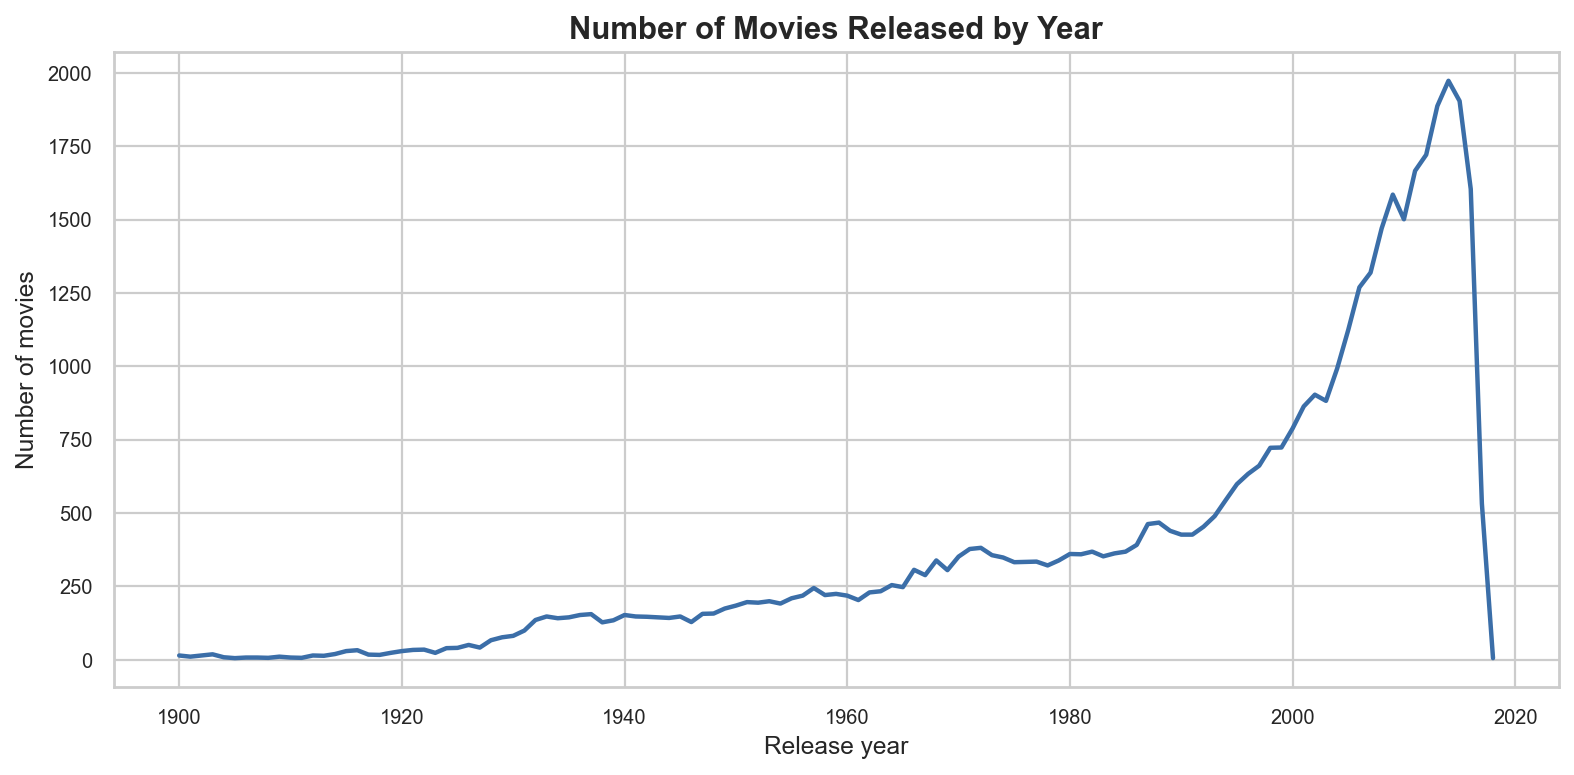

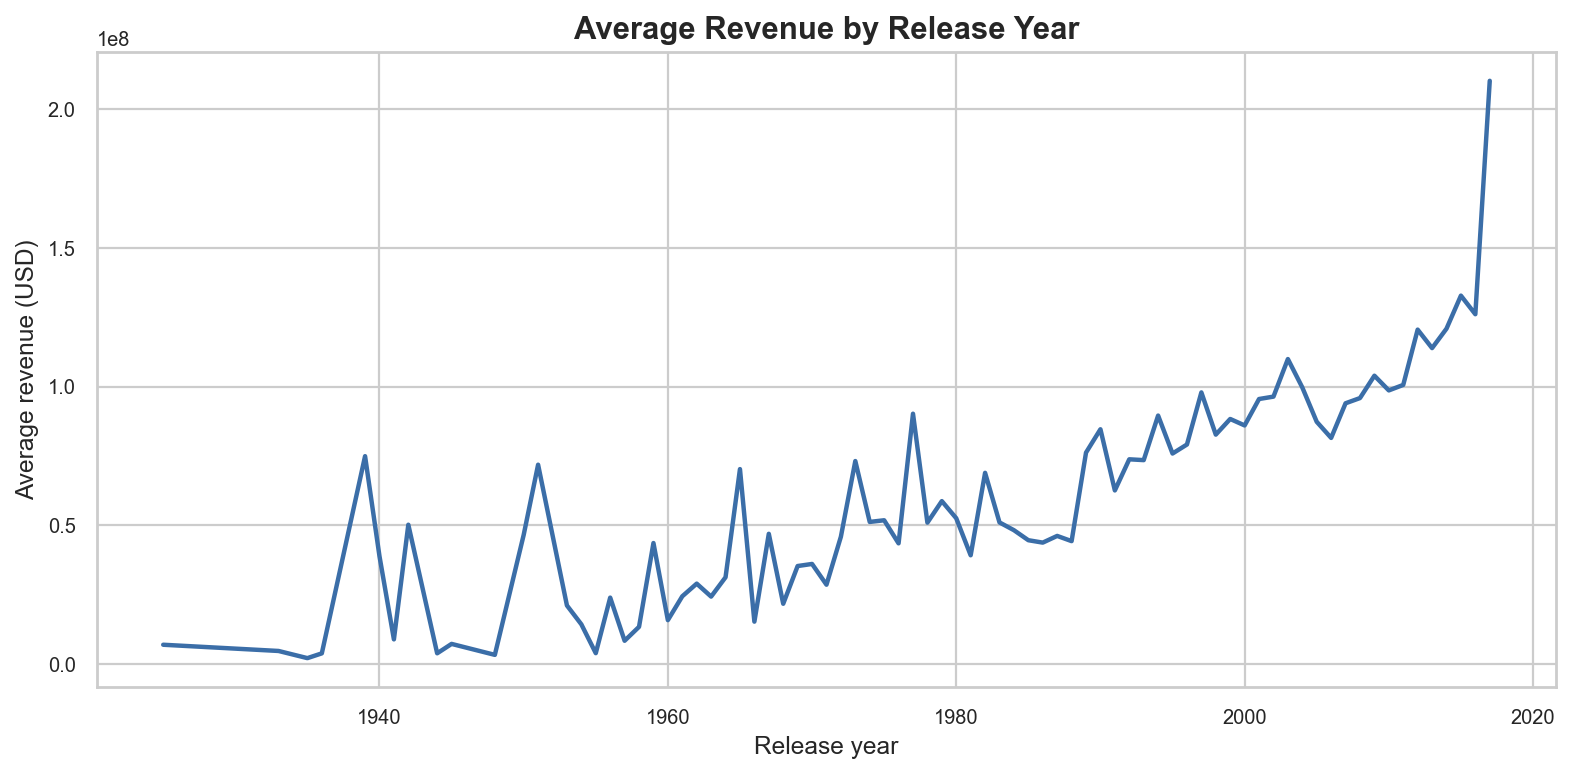

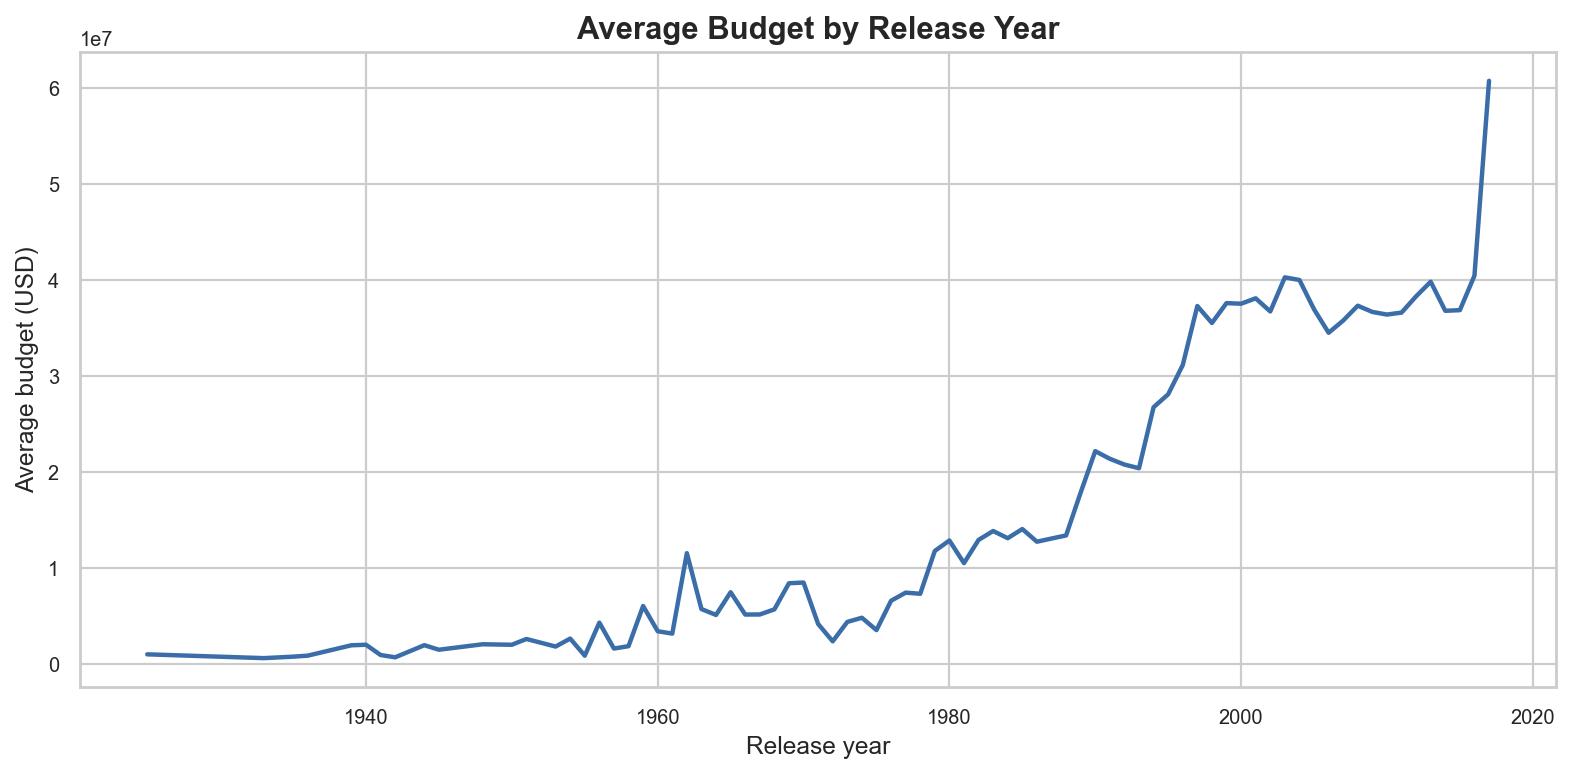

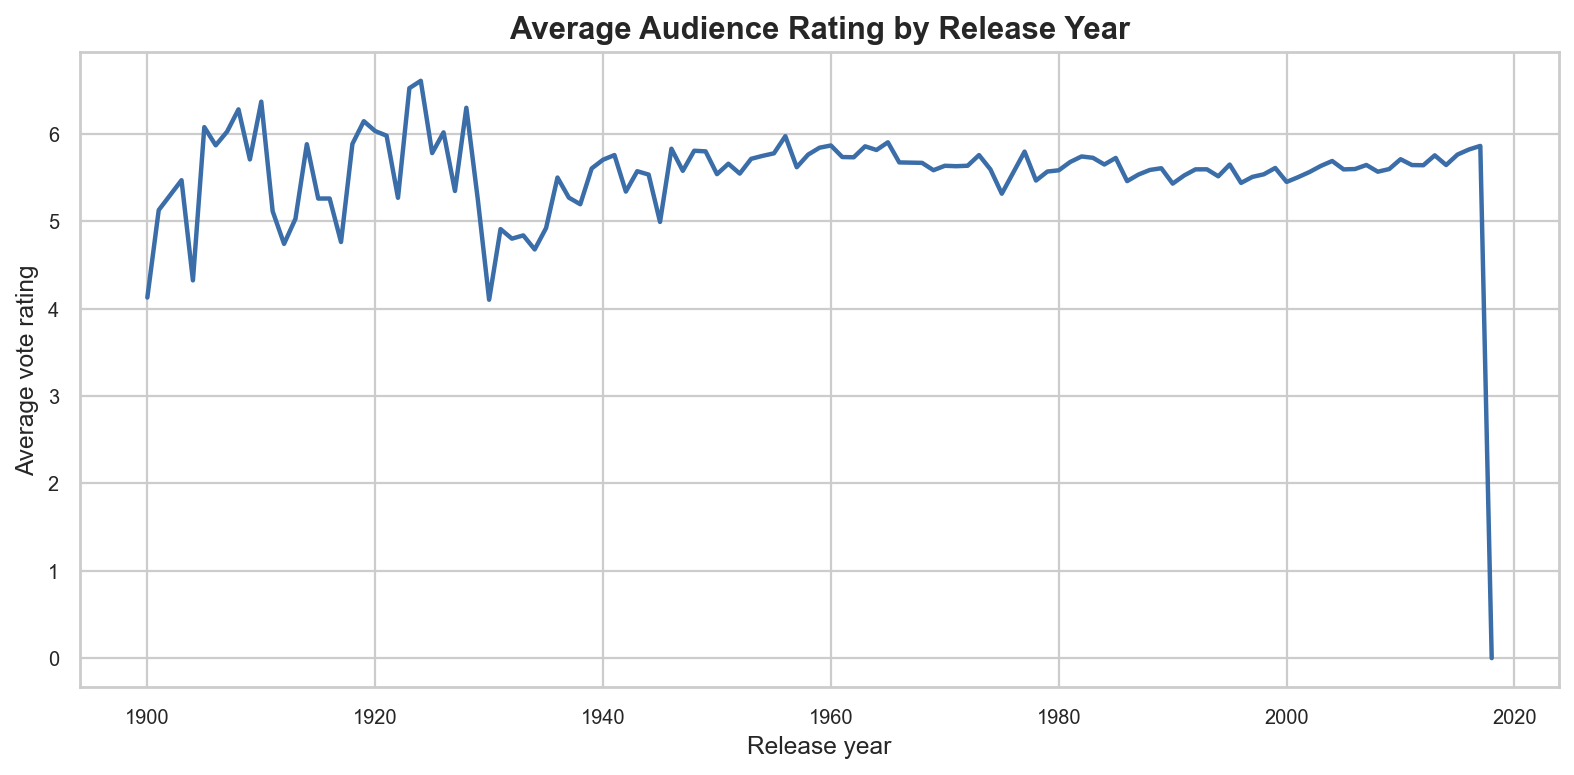

In [15]:
for figure_name in ["movies_by_year.png", "revenue_by_year.png", "budget_by_year.png", "rating_by_year.png"]:
    path = figure_paths.get(figure_name)
    if path:
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**Skipped `{figure_name}`:** {skipped_figures.get(figure_name)}"))

**Short interpretation:** The dataset shows major changes in release volume and financial scale over time. Revenue and budget trends generally reflect industry scale and blockbuster economics, while average audience rating does not move in the same way. Production volume, money, and audience evaluation therefore describe different parts of industry change.

# 9. Main Findings

This section summarizes the four analysis modules in presentation-friendly terms.

In [16]:
top_revenue_genre = genre_revenue.iloc[0]["main_genre"] if not genre_revenue.empty else "Unavailable"
top_rating_genre = genre_rating.iloc[0]["main_genre"] if not genre_rating.empty else "Unavailable"
top_roi_genre = genre_roi.iloc[0]["main_genre"] if not genre_roi.empty else "Unavailable"
strongest_audience_signal = audience_corr.drop(labels=["revenue"], errors="ignore").idxmax()
strongest_audience_corr = audience_corr.drop(labels=["revenue"], errors="ignore").max()

main_findings = [
    f"1. Higher-budget movies tend to earn higher revenue (correlation {commercial_stats['budget_revenue_corr']:.2f}), but ROI does not simply increase with budget.",
    f"2. Genre matters, but not in one single way: {top_revenue_genre} ranks highest by average revenue, while {top_rating_genre} ranks highest by average rating in the filtered genre tables.",
    f"3. Audience attention is more closely related to revenue than rating alone; {strongest_audience_signal} has the strongest revenue correlation among the audience variables ({strongest_audience_corr:.2f}).",
    f"4. Movie release volume and financial scale change over time, but average rating follows a different pattern and should not be treated as a direct financial trend.",
]

display(Markdown("\n".join(main_findings)))

1. Higher-budget movies tend to earn higher revenue (correlation 0.73), but ROI does not simply increase with budget.
2. Genre matters, but not in one single way: Animation ranks highest by average revenue, while Animation ranks highest by average rating in the filtered genre tables.
3. Audience attention is more closely related to revenue than rating alone; vote_count has the strongest revenue correlation among the audience variables (0.77).
4. Movie release volume and financial scale change over time, but average rating follows a different pattern and should not be treated as a direct financial trend.

# 10. Limitations and Future Work

**Limitations**

- Budget and revenue contain many zero or missing values, so financial conclusions only represent movies with valid positive financial data.
- `main_genre` uses the first listed genre, which simplifies movies that belong to multiple genres.
- Revenue and budget are not adjusted for inflation, so older and newer films are not perfectly comparable in financial terms.
- The dataset appears to be incomplete for the most recent years in the file, so recent time trends should be interpreted carefully.
- This step does not use `credits.csv`, `keywords.csv`, links, or ratings tables beyond inventory.

**Future work**

- Later steps can merge credits, keywords, and user ratings when the project scope expands.
- Later steps can add machine learning or recommendation-system features, but they are intentionally excluded from Step 1.
- Future analysis could adjust revenue and budget for inflation and use multi-genre analysis instead of only the first listed genre.

In [17]:
generated_figures = sorted(path.name for path in FIGURES_DIR.glob("*.png"))

summary_md = f'''# IMDB Movies Dataset Analysis: Step 1 Summary

## Project Objective

This Step 1 analysis studies **what factors are associated with movie success** using data cleaning, exploratory data analysis, and visualization. Success is considered through commercial performance, investment efficiency, audience response, and industry trends. Machine learning, recommendation systems, and LLM-related features are not included in this step.

## Dataset Overview

- Detected CSV files: {', '.join(inventory['csv_files'])}
- Main dataset: `movies_metadata.csv`
- Shape of `movies_metadata.csv`: {inventory['movies_shape'][0]:,} rows x {inventory['movies_shape'][1]:,} columns
- Duplicate movie count based on numeric id: {inventory['duplicate_movie_count']:,}
- Invalid budget rows for financial analysis: {inventory['invalid_budget_rows']:,}
- Invalid revenue rows for financial analysis: {inventory['invalid_revenue_rows']:,}
- Rows usable for financial analysis before duplicate removal: {inventory['financial_analysis_rows']:,}
- Malformed/non-numeric movie id rows: {inventory['malformed_id_rows']:,}

### Main Columns in `movies_metadata.csv`

{', '.join('`' + col + '`' for col in inventory['movies_columns'])}

### Key Column Data Types

{chr(10).join('- `' + col + '`: ' + dtype for col, dtype in inventory['key_dtypes'].items())}

### Missing Values in Key Columns

{chr(10).join('- `' + col + '`: ' + format(count, ',') for col, count in inventory['missing_values'].items())}

## Cleaning Summary

- Raw rows: {cleaning_summary['raw_rows']:,}
- Cleaned rows: {cleaning_summary['cleaned_rows']:,}
- Malformed rows removed: {cleaning_summary['malformed_rows_removed']:,}
- Duplicate rows removed: {cleaning_summary['duplicate_rows_removed']:,}
- Rows in valid financial dataset after cleaning: {cleaning_summary['financial_rows']:,}
- Financial-analysis subset saved to: `outputs/financial_movies.csv`
- Zero or negative budget/revenue values were not treated as true financial values.
- Non-financial analysis keeps as many valid movie rows as possible.

## Feature Engineering Summary

Created features include `release_year`, `genre_list`, `main_genre`, `profit`, `roi`, `budget_group`, and `rating_group`. Profit and ROI are calculated only where both budget and revenue are positive.

## Finding 1: Commercial Success

Higher-budget movies tend to achieve higher revenue. The correlation between budget and revenue is {commercial_stats['budget_revenue_corr']:.2f}, while the budget-profit correlation is {commercial_stats['budget_profit_corr']:.2f}. However, the ROI comparison by budget group shows that high-budget movies do not automatically produce stronger investment efficiency.

## Finding 2: Genre Performance

Genres perform differently depending on the success definition. In the filtered tables, `{top_revenue_genre}` has the highest average revenue, `{top_rating_genre}` has the highest average rating, and `{top_roi_genre}` has the highest average ROI. This means genre affects commercial performance and audience evaluation in different ways.

## Finding 3: Audience Response

Audience rating and commercial success are not identical. Among the audience variables, `{strongest_audience_signal}` has the strongest correlation with revenue ({strongest_audience_corr:.2f}), which suggests that audience attention is more closely related to revenue than rating score alone.

## Finding 4: Time Trend

The dataset shows changes in release volume and financial scale over time. The highest release-count year in the filtered table is {int(movies_by_year.sort_values('movie_count', ascending=False).iloc[0]['release_year'])}, with {int(movies_by_year['movie_count'].max()):,} movies. Average budget and revenue trends use only valid financial rows, while average rating does not follow the same pattern as financial scale.

## Limitations

- Financial analysis is limited to movies with positive budget and revenue.
- Budget and revenue are not inflation-adjusted.
- `main_genre` simplifies multi-genre movies to the first listed genre.
- Recent years may be incomplete in the source dataset.
- Step 1 does not merge credits, keywords, links, or ratings files.

## Future Work

Future project stages can merge additional dataset files, add richer feature engineering, and later implement machine learning or recommendation-system components. Those later features are outside Step 1.

## Generated Figures

{chr(10).join('- `outputs/figures/' + name + '`' for name in generated_figures)}
'''

SUMMARY_PATH.write_text(summary_md, encoding="utf-8")

final_checklist = pd.DataFrame([
    ("Generated cleaned dataset", CLEANED_PATH.exists(), str(CLEANED_PATH.relative_to(PROJECT_ROOT))),
    ("Generated financial dataset", FINANCIAL_PATH.exists(), str(FINANCIAL_PATH.relative_to(PROJECT_ROOT))),
    ("Generated notebook", (PROJECT_ROOT / "notebooks" / "01_data_analysis.ipynb").exists(), "notebooks/01_data_analysis.ipynb"),
    ("Generated summary file", SUMMARY_PATH.exists(), str(SUMMARY_PATH.relative_to(PROJECT_ROOT))),
    ("Generated figures", len(generated_figures) >= 14, f"{len(generated_figures)} PNG files"),
    ("Skipped analysis", len(skipped_figures) == 0, "None" if not skipped_figures else str(skipped_figures)),
    ("Machine learning excluded", True, "No ML models implemented"),
    ("Recommendation system excluded", True, "No recommendation system implemented"),
    ("LLM features excluded", True, "No LLM features implemented"),
], columns=["Check", "Passed", "Details"])

print("Final Step 1 checklist")
display(final_checklist)
print(f"Summary written to: {SUMMARY_PATH}")

Final Step 1 checklist


,Check,Passed,Details
0,Generated cleaned dataset,True,outputs\cleaned_movies.csv
1,Generated financial dataset,True,outputs\financial_movies.csv
2,Generated notebook,True,notebooks/01_data_analysis.ipynb
3,Generated summary file,True,outputs\data_analysis_summary.md
4,Generated figures,True,14 PNG files
5,Skipped analysis,True,None
6,Machine learning excluded,True,No ML models implemented
7,Recommendation system excluded,True,No recommendation system implemented
8,LLM features excluded,True,No LLM features implemented


Summary written to: C:\Users\刘子豪\Desktop\code\IMDB_analysis\outputs\data_analysis_summary.md
